In [396]:
import matplotlib.pyplot as plt
from matplotlib import font_manager
import seaborn as sns
import pandas as pd
import re
from IPython.display import display
from datetime import datetime
from operator import attrgetter
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import unicodedata
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering
from sklearn.mixture import GaussianMixture



In [397]:
MembresActius = pd.read_csv('BBDDMembresActius.csv', sep=',')
CreditMembres = pd.read_csv('BBDDCreditMembres.csv', sep=',')
EvolucioMembres = pd.read_csv('BBDDEvolucioMembres.csv', sep=',', parse_dates=["Alta", "UltimPagament"])
VisitesiCanvis = pd.read_csv('BBDDVisitesiCanvis.csv', sep=',', parse_dates=["Data de la Visita"])
VisitesiCanvis['Data de la Visita'] = pd.to_datetime(VisitesiCanvis['Data de la Visita'], format='%d/%m/%Y, %H:%M', errors='coerce')

# Clustering

## Preparacion de datos para Clustering

#### Merge

In [398]:
VisitesiCanvis

,Membre,Month name of Data de la Visita,Data de la Visita,Nº de Canvis,Month abbrev
0,Not found,September,2024-09-03 20:03:00,4.0,Sep
1,Not found,September,2024-09-03 19:52:00,NaN,Sep
2,Not found,September,2024-09-04 05:25:00,NaN,Sep
3,Roberta Causa,July,2025-07-04 18:48:00,2.0,Jul
4,Aleksandra Grechuta,July,2025-07-03 17:53:00,1.0,Jul
...,...,...,...,...,...
417,marta,April,2025-04-09 19:51:00,5.0,Apr
418,Jana Ds,April,2025-04-11 12:41:00,3.0,Apr
419,Francisca Liñan Martin,May,2025-05-21 19:34:00,NaN,May
420,Francisca Liñan Martin,May,2025-05-21 19:34:00,NaN,May


In [399]:
Clustering = VisitesiCanvis.groupby('Membre')['Data de la Visita'].count().sort_values(ascending=False).reset_index(name='visit_count')
SumaCanvisCliente = VisitesiCanvis.groupby('Membre')['Nº de Canvis'].sum().sort_values(ascending=False).reset_index(name='sum_canvi')
Clustering = Clustering.merge(SumaCanvisCliente, on='Membre')
Clustering['Membre'] = Clustering['Membre'].str.strip().str.lower().str.replace(r'\s+', ' ', regex=True)

def quitar_acentos(texto):
    if pd.isnull(texto):
        return texto
    return ''.join(
        c for c in unicodedata.normalize('NFKD', str(texto))
        if not unicodedata.combining(c)
    )

def limpiar_texto(texto):
    if pd.isnull(texto):
        return texto
    texto = str(texto).lower()
    texto = unicodedata.normalize('NFKD', texto)
    texto = ''.join(c for c in texto if not unicodedata.combining(c))
    texto = re.sub(r'\s+', ' ', texto)  # Espacios múltiples → uno solo
    return texto.strip()

Clustering['Membre'] = Clustering['Membre'].apply(quitar_acentos)
Clustering['Membre'] = Clustering['Membre'].apply(limpiar_texto)

EvolucioMembres['Membre'] = EvolucioMembres['Membre'].str.strip().str.lower().str.replace(r'\s+', ' ', regex=True)
MembresActius['Membre'] = MembresActius['Membre'].str.strip().str.lower().str.replace(r'\s+', ' ', regex=True)

def quitar_acentos(texto):
    if pd.isnull(texto):
        return texto
    return ''.join(
        c for c in unicodedata.normalize('NFKD', str(texto))
        if not unicodedata.combining(c)
    )

def limpiar_texto(texto):
    if pd.isnull(texto):
        return texto
    texto = str(texto).lower()
    texto = unicodedata.normalize('NFKD', texto)
    texto = ''.join(c for c in texto if not unicodedata.combining(c))
    texto = re.sub(r'\s+', ' ', texto)  # Espacios múltiples → uno solo
    return texto.strip()

EvolucioMembres['Membre'] = EvolucioMembres['Membre'].apply(quitar_acentos)
MembresActius['Membre'] = MembresActius['Membre'].apply(quitar_acentos)

EvolucioMembres['Membre'] = EvolucioMembres['Membre'].apply(limpiar_texto)

EvolucioMembres['Membre'] = EvolucioMembres['Membre'].replace(
    'miljana lakiƒaeviƒa',
    'miljana lakicevic'
)

EvolucioiMembresActius = pd.merge(EvolucioMembres, MembresActius, on='Membre', how='outer')
EvolucioiMembresActius = EvolucioiMembresActius.sort_values(['Membre', 'Alta_y'], ascending=[True, False])
EvolucioiMembresActius = EvolucioiMembresActius.drop_duplicates(subset='Membre', keep='first').reset_index(drop=True)
EvolucioiMembresActius['status_boolean'] = np.where(EvolucioiMembresActius['Estat'] == 'active', 1, 0)
MembreiStatusBoolean = EvolucioiMembresActius[['Membre','status_boolean']].drop_duplicates().reset_index(drop=True)
MembreiStatusBoolean.groupby('status_boolean')['Membre'].count()
Clustering = Clustering.merge(MembreiStatusBoolean, on='Membre', how='outer')
Clustering = Clustering[Clustering['Membre'] != 'not found']
Clustering

,Membre,visit_count,sum_canvi,status_boolean
0,a fernandez,NaN,NaN,0.0
1,adria linares i prenafeta,2.0,2.0,1.0
2,adriana alarcon torrella,4.0,28.0,1.0
3,adriana iri,15.0,39.0,1.0
4,agnes fauro sierra,NaN,NaN,1.0
...,...,...,...,...
235,wendy fajardo,11.0,20.0,0.0
236,xavi perez,1.0,0.0,1.0
237,xenia antras agut,NaN,NaN,1.0
238,xiaohan shi,2.0,3.0,0.0


In [400]:
def mensualizar_cuota(valor):
    if valor in [99, 139]:
        return valor / 12
    else:
        return valor

EvolucioiMembresActius['QuotaNorm'] = EvolucioiMembresActius['TipoQuota'].apply(mensualizar_cuota).round(2)
EvolucioiMembresActius.groupby('QuotaNorm')['Membre'].count()
QuotaNormalizada = EvolucioiMembresActius[['Membre','QuotaNorm']]
Clustering = Clustering.merge(QuotaNormalizada, left_on='Membre', right_on='Membre', how='outer')
Clustering

,Membre,visit_count,sum_canvi,status_boolean,QuotaNorm
0,a fernandez,NaN,NaN,0.0,10.0
1,adria linares i prenafeta,2.0,2.0,1.0,10.0
2,adriana alarcon torrella,4.0,28.0,1.0,10.0
3,adriana iri,15.0,39.0,1.0,10.0
4,agnes fauro sierra,NaN,NaN,1.0,10.0
...,...,...,...,...,...
234,wendy fajardo,11.0,20.0,0.0,10.0
235,xavi perez,1.0,0.0,1.0,10.0
236,xenia antras agut,NaN,NaN,1.0,10.0
237,xiaohan shi,2.0,3.0,0.0,10.0


In [410]:
CreditMembres['Membre'] = CreditMembres['Membre'].str.strip().str.lower().str.replace(r'\s+', ' ', regex=True)

def quitar_acentos(texto):
    if pd.isnull(texto):
        return texto
    return ''.join(
        c for c in unicodedata.normalize('NFKD', str(texto))
        if not unicodedata.combining(c)
    )

def limpiar_texto(texto):
    if pd.isnull(texto):
        return texto
    texto = str(texto).lower()
    texto = unicodedata.normalize('NFKD', texto)
    texto = ''.join(c for c in texto if not unicodedata.combining(c))
    texto = re.sub(r'\s+', ' ', texto)  # Espacios múltiples → uno solo
    return texto.strip()

CreditMembres['Membre'] = CreditMembres['Membre'].apply(quitar_acentos)
CreditMembres['Membre'] = CreditMembres['Membre'].apply(limpiar_texto)
CreditMembres = CreditMembres[CreditMembres['Membre'] != 'not found']
CreditUsuari = CreditUsuari.rename(columns={"membre": "Membre"})
Clustering = Clustering.merge(CreditUsuari, on='Membre', how='outer')

In [417]:
LifetimeMeses = EvolucioiMembresActius[['Membre', 'Antiguitat']]
Clustering = Clustering.merge(LifetimeMeses, on='Membre', how='outer')

In [443]:
VisitesiCanvis = VisitesiCanvis[VisitesiCanvis['Membre'] != 'Not found']
Clustering = Clustering[Clustering['Membre'].notna()]
VisitesiCanvis['Membre'] = VisitesiCanvis['Membre'].str.strip().str.lower().str.replace(r'\s+', ' ', regex=True)

def quitar_acentos(texto):
    if pd.isnull(texto):
        return texto
    return ''.join(
        c for c in unicodedata.normalize('NFKD', str(texto))
        if not unicodedata.combining(c)
    )

def limpiar_texto(texto):
    if pd.isnull(texto):
        return texto
    texto = str(texto).lower()
    texto = unicodedata.normalize('NFKD', texto)
    texto = ''.join(c for c in texto if not unicodedata.combining(c))
    texto = re.sub(r'\s+', ' ', texto)  
    return texto.strip()

VisitesiCanvis['Membre'] = VisitesiCanvis['Membre'].apply(quitar_acentos)
VisitesiCanvis['Membre'] = VisitesiCanvis['Membre'].apply(limpiar_texto)
VisitesiCanvis = VisitesiCanvis.sort_values('Data de la Visita', ascending=False)
VisitesiCanvis = VisitesiCanvis.drop_duplicates(subset='Membre', keep='first').reset_index(drop=True)
DataVisita = VisitesiCanvis[['Membre', 'Data de la Visita']]
fecha_corte = pd.to_datetime('2025-07-05')
DataVisita['Data de la Visita'] = pd.to_datetime(DataVisita['Data de la Visita'], errors='coerce')
DataVisita['recencia_dias'] = (fecha_corte - DataVisita['Data de la Visita']).dt.days
RecenciaDias = DataVisita[['Membre', 'recencia_dias']]
Clustering = Clustering.merge(RecenciaDias, on='Membre', how='outer')
Clustering['recencia_dias'] = Clustering['recencia_dias'].fillna(999)

/var/folders/y0/7f28l5651dd29dl8fv5rq_nw0000gn/T/ipykernel_8818/766914711.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  DataVisita['Data de la Visita'] = pd.to_datetime(DataVisita['Data de la Visita'], errors='coerce')
/var/folders/y0/7f28l5651dd29dl8fv5rq_nw0000gn/T/ipykernel_8818/766914711.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  DataVisita['recencia_dias'] = (fecha_corte - DataVisita['Data de la Visita']).dt.days


In [314]:
Clustering

,customer,VisitCount,SumCanvi,StatusBoolean,QuotaNorm,Credits,Lifetime_meses,recencia_dias
0,a fernandez,0.0,0.0,0.0,10.0,2.0,7.0,999.0
1,adria linares i prenafeta,2.0,2.0,1.0,10.0,20.0,7.0,81.0
2,adriana alarcon torrella,4.0,28.0,1.0,10.0,82.0,6.0,56.0
3,adriana iri,15.0,39.0,1.0,10.0,80.0,8.0,4.0
4,agnes fauro sierra,0.0,0.0,1.0,10.0,8.0,8.0,999.0
...,...,...,...,...,...,...,...,...
236,xavi perez,1.0,0.0,1.0,10.0,12.0,8.0,231.0
237,xenia antras agut,0.0,0.0,1.0,10.0,18.0,8.0,999.0
238,xiaohan shi,2.0,3.0,0.0,10.0,1.0,3.0,50.0
239,youssef charkaoui koubaa,0.0,0.0,0.0,10.0,12.0,7.0,999.0


In [318]:
features = ['VisitCount', 'SumCanvi', 'StatusBoolean', 'QuotaNorm',
            'Credits', 'Lifetime_meses', 'recencia_dias']

X = Clustering[features]
X

,VisitCount,SumCanvi,StatusBoolean,QuotaNorm,Credits,Lifetime_meses,recencia_dias
0,0.0,0.0,0.0,10.0,2.0,7.0,999.0
1,2.0,2.0,1.0,10.0,20.0,7.0,81.0
2,4.0,28.0,1.0,10.0,82.0,6.0,56.0
3,15.0,39.0,1.0,10.0,80.0,8.0,4.0
4,0.0,0.0,1.0,10.0,8.0,8.0,999.0
...,...,...,...,...,...,...,...
235,11.0,20.0,0.0,10.0,3.0,5.0,18.0
236,1.0,0.0,1.0,10.0,12.0,8.0,231.0
237,0.0,0.0,1.0,10.0,18.0,8.0,999.0
238,2.0,3.0,0.0,10.0,1.0,3.0,50.0


#### Variables (normales, o no, outliers o no, etc)

##### Visit Count: numerica, no normal, con outliers

<Axes: xlabel='VisitCount', ylabel='Density'>

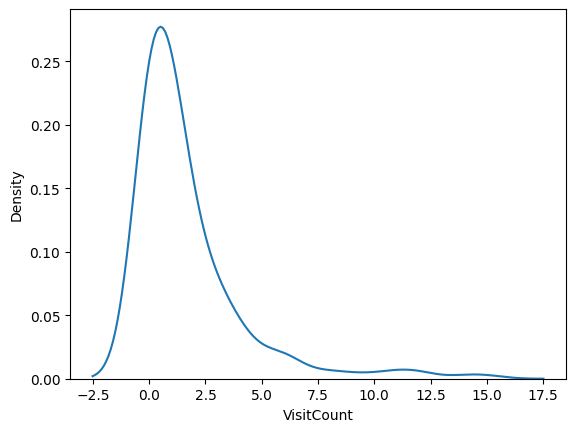

In [ ]:
sns.kdeplot(X.VisitCount)

<Axes: ylabel='VisitCount'>

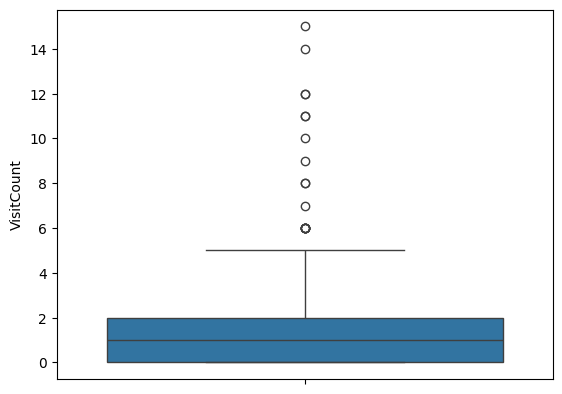

In [320]:
sns.boxplot(X.VisitCount)

##### SumCanvi, numerica, no normal con outliers

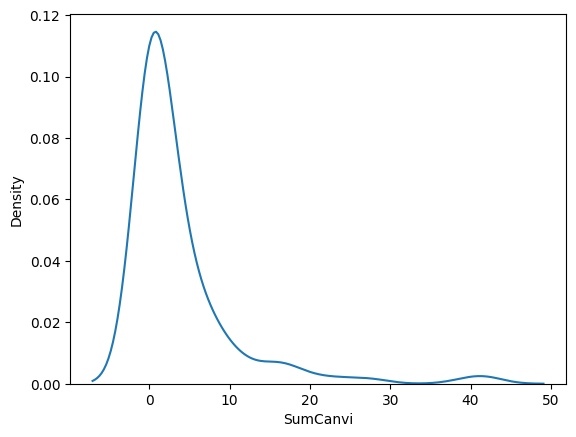

In [321]:
sns.kdeplot(X.SumCanvi);

<Axes: ylabel='SumCanvi'>

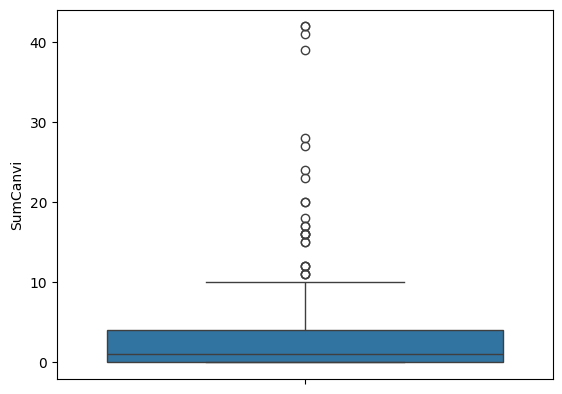

In [322]:
sns.boxplot(X.SumCanvi)

##### QuotaMensualNorm numerica, no normal con outliers

In [323]:
sns.kdeplot(X.QuotaMensualNorm);

AttributeError: 'DataFrame' object has no attribute 'QuotaMensualNorm'

<Axes: ylabel='QuotaMensualNorm'>

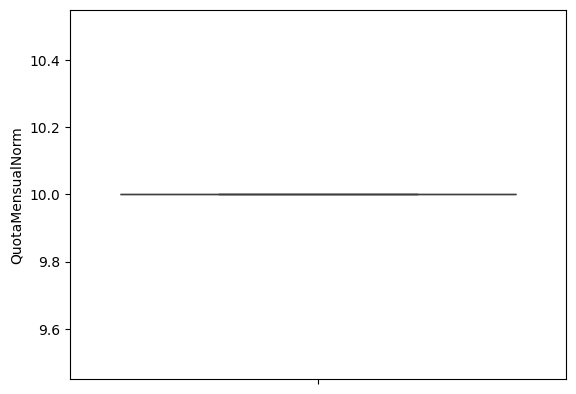

In [106]:
sns.boxplot(X.QuotaMensualNorm)

##### Credits, numerica, no normal con outliers

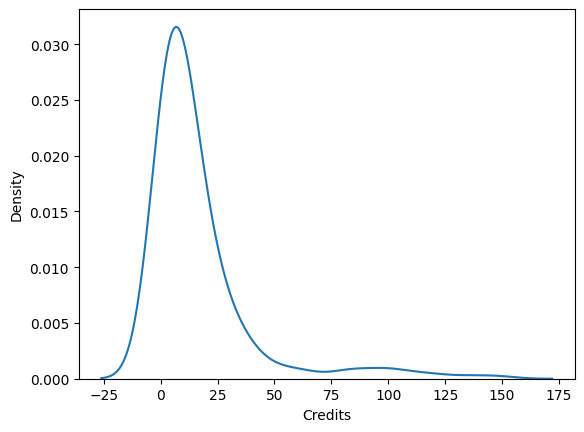

In [ ]:
sns.kdeplot(X.Credits);

<Axes: ylabel='Credits'>

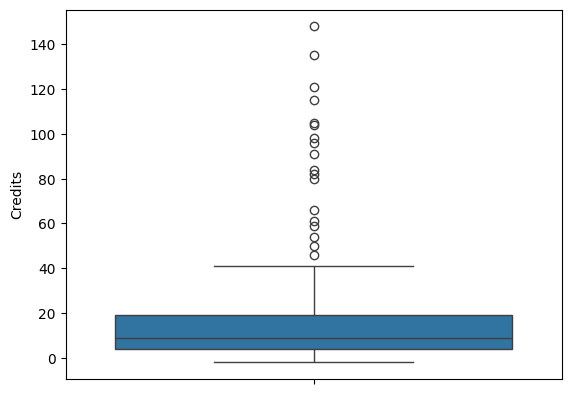

In [108]:
sns.boxplot(X.Credits)

##### Lifetime_meses, numerica, no normal SIN outliers

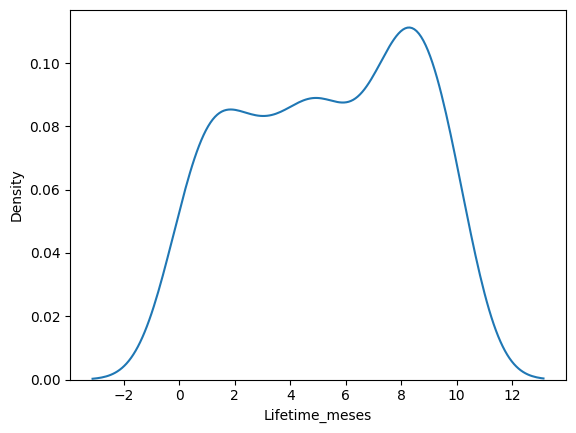

In [ ]:
sns.kdeplot(X.Lifetime_meses);

<Axes: ylabel='Lifetime_meses'>

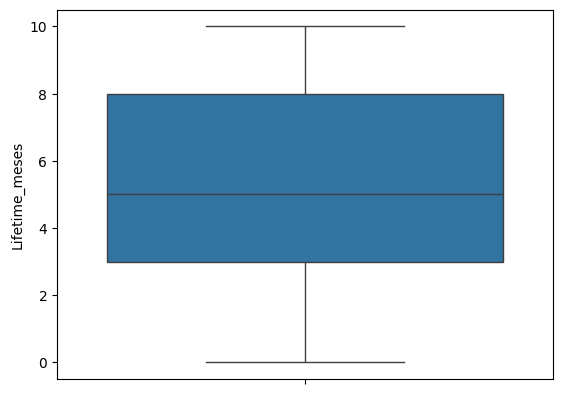

In [110]:
sns.boxplot(X.Lifetime_meses)

##### recencia_dias, numerica, no normal SIN outliers

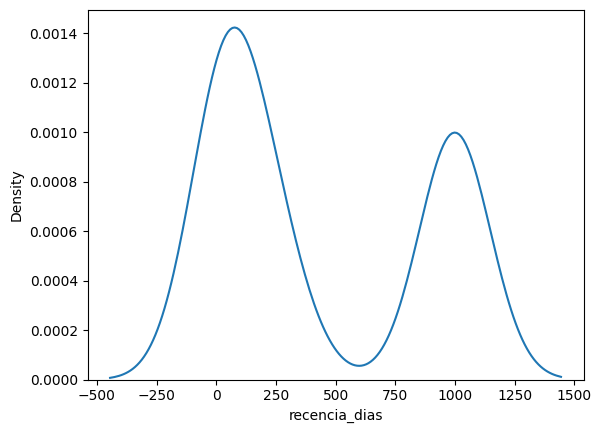

In [ ]:
sns.kdeplot(X.recencia_dias);

<Axes: ylabel='recencia_dias'>

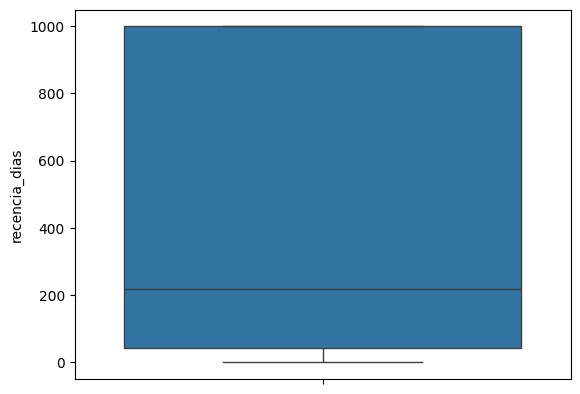

In [ ]:
sns.boxplot(X.recencia_dias)

In [113]:
from scipy.stats import shapiro

data = [X]
stat, p = shapiro(data)
print('Estadístico=%.3f, p=%.3f' % (stat, p))
if p > 0.05:
    print("Los datos parecen seguir una distribución normal")
else:
    print("Los datos NO parecen seguir una distribución normal")


Estadístico=nan, p=nan
Los datos NO parecen seguir una distribución normal


#### Features

In [325]:
X = X.fillna(0)
X = X[X['QuotaNorm']!= 0]
X[X['QuotaNorm']== 0]

,VisitCount,SumCanvi,StatusBoolean,QuotaNorm,Credits,Lifetime_meses,recencia_dias


In [326]:
#Numericas a escalar
features_with_outliers = ['VisitCount', 'SumCanvi', 'QuotaNorm', 'Credits']
features_without_outliers = [ 'Lifetime_meses', 'recencia_dias']

features_with_outliers_df = X[features_with_outliers]
features_without_outliers_df = X[features_without_outliers]

# Robust
columnas_originales = features_with_outliers_df.columns
scaler = RobustScaler()
features_with_outliers_df_robust = scaler.fit_transform(features_with_outliers_df)
features_with_outliers_df_robust_df = pd.DataFrame(features_with_outliers_df_robust, columns=columnas_originales)

# MinMax
scaler_minmax = MinMaxScaler()
features_without_outliers_minmax = scaler_minmax.fit_transform(features_without_outliers_df)
features_without_outliers_minmax_df = pd.DataFrame(features_without_outliers_minmax, columns=features_without_outliers_df.columns)
features_without_outliers_minmax_df

features_with_outliers_df_robust_df = features_with_outliers_df_robust_df.reset_index(drop=True)
features_without_outliers_minmax_df = features_without_outliers_minmax_df.reset_index(drop=True)
status_boolean = X['StatusBoolean'].reset_index(drop=True)

features_df = pd.concat([features_with_outliers_df_robust_df, features_without_outliers_minmax_df, status_boolean],axis=1)
features_df


,VisitCount,SumCanvi,QuotaNorm,Credits,Lifetime_meses,recencia_dias,StatusBoolean
0,-0.5,-0.25,0.0,-0.466667,0.7,1.000000,0.0
1,0.5,0.25,0.0,0.733333,0.7,0.081081,1.0
2,1.5,6.75,0.0,4.866667,0.6,0.056056,1.0
3,7.0,9.50,0.0,4.733333,0.8,0.004004,1.0
4,-0.5,-0.25,0.0,-0.066667,0.8,1.000000,1.0
...,...,...,...,...,...,...,...
233,5.0,4.75,0.0,-0.400000,0.5,0.018018,0.0
234,0.0,-0.25,0.0,0.200000,0.8,0.231231,1.0
235,-0.5,-0.25,0.0,0.600000,0.8,1.000000,1.0
236,0.5,0.50,0.0,-0.533333,0.3,0.050050,0.0


## Kmeans

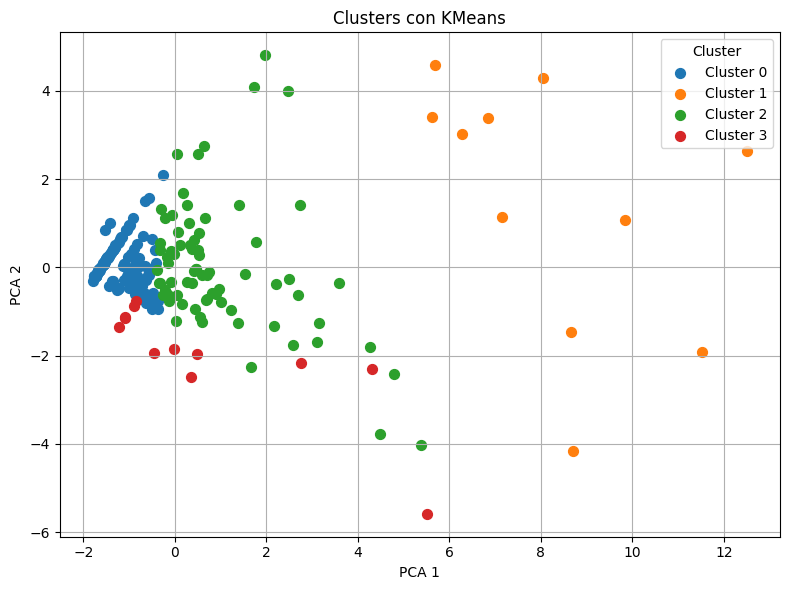

In [330]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

# Suponiendo que features_df ya está escalado con MinMaxScaler

kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(features_df)
features_df['cluster_kmeans'] = clusters

# Reducción de dimensión con PCA (excluyendo la columna de cluster)
pca = PCA(n_components=2)
features_df_pca = pca.fit_transform(features_df.drop(columns='cluster_kmeans'))

# Convertir a DataFrame para fácil manejo
pca_df = pd.DataFrame(features_df_pca, columns=['PCA1', 'PCA2'])
pca_df['cluster'] = features_df['cluster_kmeans']

# Plot con leyenda categórica
plt.figure(figsize=(8, 6))

# Graficar cada cluster por separado
for cluster_id in sorted(pca_df['cluster'].unique()):
    cluster_data = pca_df[pca_df['cluster'] == cluster_id]
    plt.scatter(cluster_data['PCA1'], cluster_data['PCA2'],
                label=f'Cluster {cluster_id}', s=50)

plt.title('Clusters con KMeans')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.tight_layout()
plt.show()


In [117]:
pca.explained_variance_ratio_

array([0.60076083, 0.16952658])

In [118]:
pd.DataFrame(
    pca.components_,
    columns=features_df.drop(columns='cluster_kmeans').columns,
    index=['PCA1', 'PCA2']
)

,VisitCount,SumCanvi,QuotaMensualNorm,Credits,Lifetime_meses,recencia_dias,StatusBoolean
PCA1,0.445589,0.714140,0.053817,0.524170,0.040129,-0.098003,0.050887
PCA2,-0.363394,-0.340179,-0.308225,0.804849,0.017271,0.052835,0.079679
